In [18]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Optional

In [19]:
class StateBatsman(TypedDict, total= False):
    runs : int
    balls : int
    sixs : int
    fours : int

    sr : float
    boundary_per : float
    balls_pr_bound : float
    summary : str

In [ ]:
def calculate_strike_rate(state : StateBatsman):
    sr = (state['runs']/state['balls']) * 100
    return {'sr' : round(sr, 2)} # return only new updated field as dict.

In [39]:
def calculate_boundary_percentage(state : StateBatsman):
    boundary_per = ((4 * state['fours']) + (6 * state['sixs'])/state['runs']) * 100
    return {'boundary_per' : round(boundary_per, 2)}

In [40]:
def calculate_balls_per_boundary(state : StateBatsman):
    balls_pr_bound= state['balls']/state['fours'] + state['sixs']
    return {'balls_pr_bound' : round(balls_pr_bound, 2)}

In [53]:
def summary(state : StateBatsman):
    summary = f''' Strike-Rate {state['sr']} 
            Boundary % {state['boundary_per']}
            Balls Per Boundary {state['balls_pr_bound']}'''
    return {'summary' : summary}

In [ ]:
graph = StateGraph(StateBatsman)

graph.add_node('calculate_strike_rate', calculate_strike_rate)
graph.add_node('calculate_boundary_percentage', calculate_boundary_percentage)
graph.add_node('calculate_balls_per_boundary', calculate_balls_per_boundary)
graph.add_node('summary', summary)

# Due to Parallel workflow. We use 3 'START' statements.
graph.add_edge(START, 'calculate_strike_rate')
graph.add_edge(START, 'calculate_boundary_percentage')
graph.add_edge(START, 'calculate_balls_per_boundary')

graph.add_edge('calculate_strike_rate', 'summary')
graph.add_edge('calculate_boundary_percentage', 'summary')
graph.add_edge('calculate_balls_per_boundary', 'summary')
graph.add_edge('summary', END)

workflow = graph.compile()

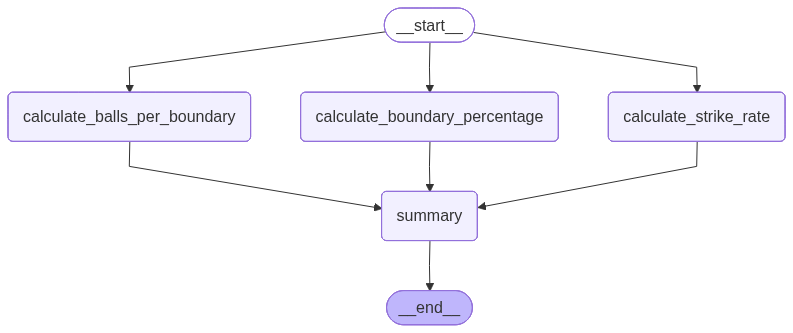

In [55]:
workflow

In [56]:
user_query = {
    'runs' : 78,
    'balls' : 34,
    'sixs' : 2,
    'fours' : 6
}

workflow.invoke(user_query)

{'runs': 78,
 'balls': 34,
 'sixs': 2,
 'fours': 6,
 'sr': 229.41,
 'boundary_per': 2415.38,
 'balls_pr_bound': 7.67,
 'summary': ' Strike-Rate 229.41 \n            Boundary % 2415.38\n            Balls Per Boundary 7.67'}